### Test Forward Pass (Final Ranker)

In [1]:
import torch
input_size = 100
x = torch.randn(1000, input_size)

In [2]:
from Ads import FinalRankerMMoE

final_ranker = FinalRankerMMoE(input_size=input_size,
                               layers=2,
                               expert_num=4,
                               expert_dims=[256],
                               task_dims=[[256, 128, 64, 1], [256, 128, 64, 1]],
                               top_k=4)


/Users/paataugrekhelidze/Projects/Recsys/ranking/ads_Moe/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
out = final_ranker(x)
for task in range(len(out)):
    print(task, out[task].shape)

0 torch.Size([1000, 1])
1 torch.Size([1000, 1])


### Test Forward Pass (DLRM towers-only, early-stage ranker)

In [4]:
from Ads import DLRMTower, EmbeddingLayer

bottom_mlp_layers = [512, 256, 64]
projection_layer = 128
emb_layers = {
    "uid": int(2e6),
    "campaign": 401, # +1 for null at index 400
    "cat1": 10,
    "cat2": 70,
    "cat3": 1829,
    "cat4": 21,
    "cat5": 51,
    "cat6": 30,
    "cat7": 57196,
    "cat8": 11,
    "cat9": 30,
}

sparse_features = [ "uid", 
                   "campaign", 
                   "cat1", 
                   "cat2",
                   "cat3",
                   "cat4",
                   "cat5",
                   "cat6",
                   "cat7",
                   "cat8",
                   "cat9",
                   "last_n_click_campaigns_1D",
                   "last_n_conversion_campaigns_1D"]

E = EmbeddingLayer(emb_layers=emb_layers, emb_dim=bottom_mlp_layers[-1])

model = DLRMTower(
            bottom_mlp_layers=bottom_mlp_layers,
            projection_layer=projection_layer,
            embs=E.embs,
            sparse_num=len(sparse_features),
            dense_num=0, # no dense features
            device="cpu"
        )
model

DLRMTower(
  (embs): ModuleDict(
    (uid): QREmbeddingBag([1415, 1414], [64, 64], mode=mean)
    (campaign): QREmbeddingBag([21, 20], [64, 64], mode=mean)
    (cat1): QREmbeddingBag([4, 3], [64, 64], mode=mean)
    (cat2): QREmbeddingBag([9, 8], [64, 64], mode=mean)
    (cat3): QREmbeddingBag([44, 42], [64, 64], mode=mean)
    (cat4): QREmbeddingBag([6, 4], [64, 64], mode=mean)
    (cat5): QREmbeddingBag([8, 7], [64, 64], mode=mean)
    (cat6): QREmbeddingBag([6, 5], [64, 64], mode=mean)
    (cat7): QREmbeddingBag([240, 239], [64, 64], mode=mean)
    (cat8): QREmbeddingBag([4, 3], [64, 64], mode=mean)
    (cat9): QREmbeddingBag([6, 5], [64, 64], mode=mean)
  )
  (projection): Linear(in_features=78, out_features=128, bias=True)
)

In [5]:
# test dataloader
from datasets import Dataset
import os

filepath = "../../datasets/criteo_attribution_dataset/processed"

train_df = Dataset.from_parquet(os.path.join(filepath, 'train/train.parquet'))


In [6]:
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial

B = 2048
WORKERS = 0

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)


train_dataset = AdsDataset(data= train_df)
train_ld = DataLoader(dataset=train_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)
total = len(train_df) // B

In [7]:
iterator = iter(train_ld)
sample = next(iterator)
for k in sample.keys():
    print(k, sample[k].shape)

uid torch.Size([2048])
campaign torch.Size([2048])
cat1 torch.Size([2048])
cat2 torch.Size([2048])
cat3 torch.Size([2048])
cat4 torch.Size([2048])
cat5 torch.Size([2048])
cat6 torch.Size([2048])
cat7 torch.Size([2048])
cat8 torch.Size([2048])
cat9 torch.Size([2048])
position_0 torch.Size([2048])
position_1 torch.Size([2048])
position_2 torch.Size([2048])
position_3 torch.Size([2048])
position_4 torch.Size([2048])
position_5 torch.Size([2048])
position_6 torch.Size([2048])
position_7 torch.Size([2048])
position_8 torch.Size([2048])
position_9 torch.Size([2048])
position_10 torch.Size([2048])
position_11 torch.Size([2048])
position_12 torch.Size([2048])
position_13 torch.Size([2048])
position_14 torch.Size([2048])
position_15 torch.Size([2048])
position_16 torch.Size([2048])
position_17 torch.Size([2048])
position_18 torch.Size([2048])
position_19 torch.Size([2048])
position_20 torch.Size([2048])
position_21 torch.Size([2048])
position_22 torch.Size([2048])
position_23 torch.Size([2048])

In [5]:
emb_indices = dict()
emb_offsets = dict()
for f in sparse_features:
    emb_indices[f] = sample[f]
for f in ["last_n_click_campaigns_1D_offset", "last_n_conversion_campaigns_1D_offset"]:
    emb_offsets[f] = sample[f]

In [6]:
import torch
with torch.no_grad():
    out = model(
        dense=None,           # dense_num=0, no dense features
        emb_indices=emb_indices,
        emb_offsets=emb_offsets,
    )
print("Output shape:", out.shape)  # expected: (8, 128)

Output shape: torch.Size([2048, 128])


### Test Forward Pass (Full Early-stage ranker)

In [7]:
from Ads import EarlyRanker

# now that we have a functional DLRM tower class, we can split and represent user and item (streaming context features if we had them...) features separately

# for simplicity, keep DLRM Tower bottom and top MLPs identical between user and ad features
bottom_mlp_layers = [512, 256, 64]
projection_layer = 128
emb_layers = {
    "uid": int(2e6),
    "campaign": 401, # +1 for null at index 400
    "cat1": 10,
    "cat2": 70,
    "cat3": 1829,
    "cat4": 21,
    "cat5": 51,
    "cat6": 30,
    "cat7": 57196,
    "cat8": 11,
    "cat9": 30,
}

sparse_features = { 
    "user" : ["uid", "last_n_click_campaigns_1D", "last_n_conversion_campaigns_1D"],
    "ad"   : ["campaign", "cat1", "cat2", "cat3", "cat4", "cat5", "cat6", "cat7", "cat8", "cat9"]
}


E = EmbeddingLayer(emb_layers=emb_layers, emb_dim=bottom_mlp_layers[-1])

# define user and ad tower params
base_params = {
    "bottom_mlp_layers" : bottom_mlp_layers,
    "projection_layer" : projection_layer,
    "embs" : E.embs,
    "dense_num" : 0,
    "device" : "cpu"
}
# copy to get independent dicts
u_params  = {**base_params, "sparse_num": len(sparse_features["user"])}
ad_params = {**base_params, "sparse_num": len(sparse_features["ad"])}

shared_dims = [512, 256]
task_dims = [[128, 64, 1], [128, 64, 1], [128, 64, 1], [128, 64, 1]]

model = EarlyRanker(
    shared_dims = shared_dims,
    task_dims = task_dims,
    u_params = u_params,
    ad_params = ad_params
)


In [8]:
import torch
# define raw input for user and ad features
x = dict()

for k, features in sparse_features.items():
    emb_indices = dict()
    emb_offsets = dict()
    for f in features:
        emb_indices[f] = sample[f]
    if k == "user":
        for f in ["last_n_click_campaigns_1D_offset", "last_n_conversion_campaigns_1D_offset"]:
            emb_offsets[f] = sample[f]
    x[k] = {"dense": None, "emb_indices": emb_indices, "emb_offsets": emb_offsets}


with torch.no_grad():
    out = model(
        None, # no cache
        x
    )
for task_out in out:
    print("Output shape:", task_out.shape)  # expected: 4 x (2048, 1) for 4 separate task heads

Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])


In [10]:
# define cached user input and raw ad features
cache = {
    "user": torch.randn((B, projection_layer)),
    #"ad": torch.randn((B, projection_layer)),
}

with torch.no_grad():
    out = model(
        cache,
        x
    )
for task_out in out:
    print("Output shape:", task_out.shape)  # expected: 4 x (2048, 1) for 4 separate task heads

Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])


## Train Final Ranker

Early-stage model (student) uses distillation to better generalize and also stay consistent with a more expressive and complex final ranker (teacher). This requires the final ranker to be pretrained.

In [1]:
from Ads import FinalRankerMMoE, FullRanker, EmbeddingLayer, DLRMTower

# eval metrics
# for "simplicity", Stack DLRMTower with the final ranker. This could potentially be used to share cached values across early-stage and final rankers.
# e.g. user and ad towers are shared between the rankers, but the final ranker also includes additional context-based (streaming features) tower.

bottom_mlp_layers = [512, 256, 64]
projection_layer = 128
emb_layers = {
    "uid": int(2e6),
    "campaign": 401, # +1 for null at index 400
    "cat1": 10,
    "cat2": 70,
    "cat3": 1829,
    "cat4": 21,
    "cat5": 51,
    "cat6": 30,
    "cat7": 57196,
    "cat8": 11,
    "cat9": 30,
}

sparse_features = { 
    "user" : ["uid", "last_n_click_campaigns_1D", "last_n_conversion_campaigns_1D"],
    "ad"   : ["campaign", "cat1", "cat2", "cat3", "cat4", "cat5", "cat6", "cat7", "cat8", "cat9"]
}


E = EmbeddingLayer(emb_layers=emb_layers, emb_dim=bottom_mlp_layers[-1])

# define user and ad tower params
base_params = {
    "bottom_mlp_layers" : bottom_mlp_layers,
    "projection_layer" : projection_layer,
    "embs" : E.embs,
    "dense_num" : 0,
    "device" : "cpu"
}
# copy to get independent dicts
u_params  = {**base_params, "sparse_num": len(sparse_features["user"])}
ad_params = {**base_params, "sparse_num": len(sparse_features["ad"])}

uTower = DLRMTower(**u_params)
adTower = DLRMTower(**ad_params)


mmoe_layers = 2
expert_num = 4
expert_dims = [256]
# CTR, CVR
final_task_dims = [[256, 128, 64, 1], [256, 128, 64, 1]]
top_k = expert_num # not sparse
top_k = 2 # sparse MoE
final_ranker = FinalRankerMMoE(input_size=projection_layer*2, # input coming from user and ad towers
                               layers=mmoe_layers,
                               expert_num=expert_num,
                               expert_dims=expert_dims,
                               task_dims=final_task_dims,
                               top_k=4)

full_model = FullRanker(
    towers={"user": uTower, "ad": adTower},
    final_ranker=final_ranker
)


/Users/paataugrekhelidze/Projects/Recsys/ranking/ads_Moe/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import torch
# define raw input for user and ad features
x = dict()

for k, features in sparse_features.items():
    emb_indices = dict()
    emb_offsets = dict()
    for f in features:
        emb_indices[f] = sample[f]
    if k == "user":
        for f in ["last_n_click_campaigns_1D_offset", "last_n_conversion_campaigns_1D_offset"]:
            emb_offsets[f] = sample[f]
    x[k] = {"dense": None, "emb_indices": emb_indices, "emb_offsets": emb_offsets}


with torch.no_grad():
    out = full_model(x)

for task_out in out:
    print("Output shape:", task_out.shape)

Output shape: torch.Size([2048, 1])
Output shape: torch.Size([2048, 1])


In [9]:
full_model

FullRanker(
  (towers): ModuleDict(
    (user): DLRMTower(
      (embs): ModuleDict(
        (uid): QREmbeddingBag([1415, 1414], [64, 64], mode=mean)
        (campaign): QREmbeddingBag([21, 20], [64, 64], mode=mean)
        (cat1): QREmbeddingBag([4, 3], [64, 64], mode=mean)
        (cat2): QREmbeddingBag([9, 8], [64, 64], mode=mean)
        (cat3): QREmbeddingBag([44, 42], [64, 64], mode=mean)
        (cat4): QREmbeddingBag([6, 4], [64, 64], mode=mean)
        (cat5): QREmbeddingBag([8, 7], [64, 64], mode=mean)
        (cat6): QREmbeddingBag([6, 5], [64, 64], mode=mean)
        (cat7): QREmbeddingBag([240, 239], [64, 64], mode=mean)
        (cat8): QREmbeddingBag([4, 3], [64, 64], mode=mean)
        (cat9): QREmbeddingBag([6, 5], [64, 64], mode=mean)
      )
      (projection): Linear(in_features=3, out_features=128, bias=True)
    )
    (ad): DLRMTower(
      (embs): ModuleDict(
        (uid): QREmbeddingBag([1415, 1414], [64, 64], mode=mean)
        (campaign): QREmbeddingBag([21, 2

In [3]:
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial
from datasets import Dataset
import os

filepath = "../../datasets/criteo_attribution_dataset/processed"
train_df = Dataset.from_parquet(os.path.join(filepath, 'train/train.parquet'))

B = 2048
WORKERS = 4

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)


train_dataset = AdsDataset(data= train_df)
train_ld = DataLoader(dataset=train_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

In [ ]:
# train
import torch
from Ads import Solver
import os

checkpoint_dir = "./checkpoints/fullRanker"
os.makedirs(checkpoint_dir, exist_ok=True)


# define optimizer
emb_params = []
dense_params = []

for name, p in full_model.named_parameters():
    if not p.requires_grad:
        continue
    if "embs" in name:          # covers towers.user.embs.* and towers.ad.embs.*
        emb_params.append(p)
    else:
        dense_params.append(p)

optimizer = torch.optim.Adagrad(
    [
        {"params": emb_params,   "lr": 0.05},
        {"params": dense_params, "lr": 1e-3, "weight_decay": 1e-6},
    ],
    # starting value of the squared gradient accumulator in Adagrad.
    # if initial_accumulator_value=0 -> first step lr / sqrt(0 + ε) → very large update
    # Sparse embeddings (lr=0.05) — most embedding rows are never seen in the first few batches, so G=0 would cause huge updates on first encounter. 1e-8 softens this.
    # Dense MLPs (lr=1e-3) — less critical since dense params are updated every batch and G grows quickly anyway
    # initial_accumulator_value=1e-8,
)

solver = Solver(
    model = full_model,
    data = train_ld,
    optimizer = optimizer,
    device = "cpu",
    epochs = 10,
    checkpoint_dir = checkpoint_dir

)

solver.train()



[0/10] Loss: 0.731073 time: 62.42505054871241m
Checkpoint saved at ./checkpoints/fullRanker/checkpoint_epoch_0.pth
Checkpoint saved at ./checkpoints/fullRanker/last_checkpoint.pth
[1/10] Loss: 0.721818 time: 63.523518900076546m
Checkpoint saved at ./checkpoints/fullRanker/checkpoint_epoch_1.pth
Checkpoint saved at ./checkpoints/fullRanker/last_checkpoint.pth
[2/10] Loss: 0.717976 time: 61.65077916781107m
Checkpoint saved at ./checkpoints/fullRanker/checkpoint_epoch_2.pth
Checkpoint saved at ./checkpoints/fullRanker/last_checkpoint.pth
[3/10] Loss: 0.715498 time: 59.9249769171079m
Checkpoint saved at ./checkpoints/fullRanker/checkpoint_epoch_3.pth
Checkpoint saved at ./checkpoints/fullRanker/last_checkpoint.pth
[4/10] Loss: 0.713687 time: 62.025911319255826m
Checkpoint saved at ./checkpoints/fullRanker/checkpoint_epoch_4.pth
Checkpoint saved at ./checkpoints/fullRanker/last_checkpoint.pth
[5/10] Loss: 0.712267 time: 60.78025121688843m
Checkpoint saved at ./checkpoints/fullRanker/checkpo

[0/1705]
[1/1705]
[2/1705]
[3/1705]
[4/1705]
[5/1705]
[6/1705]
[7/1705]
[8/1705]
[9/1705]
[10/1705]
[11/1705]
[12/1705]
[13/1705]
[14/1705]
[15/1705]
[16/1705]
[17/1705]
[18/1705]
[19/1705]
[20/1705]
[21/1705]
[22/1705]
[23/1705]
[24/1705]
[25/1705]
[26/1705]
[27/1705]
[28/1705]
[29/1705]
[30/1705]
[31/1705]
[32/1705]
[33/1705]
[34/1705]
[35/1705]
[36/1705]
[37/1705]
[38/1705]
[39/1705]
[40/1705]
[41/1705]
[42/1705]
[43/1705]
[44/1705]
[45/1705]
[46/1705]
[47/1705]
[48/1705]
[49/1705]
[50/1705]
[51/1705]
[52/1705]
[53/1705]
[54/1705]
[55/1705]
[56/1705]
[57/1705]
[58/1705]
[59/1705]
[60/1705]
[61/1705]
[62/1705]
[63/1705]
[64/1705]
[65/1705]
[66/1705]
[67/1705]
[68/1705]
[69/1705]
[70/1705]
[71/1705]
[72/1705]
[73/1705]
[74/1705]
[75/1705]
[76/1705]
[77/1705]
[78/1705]
[79/1705]
[80/1705]
[81/1705]
[82/1705]
[83/1705]
[84/1705]
[85/1705]
[86/1705]
[87/1705]
[88/1705]
[89/1705]
[90/1705]
[91/1705]
[92/1705]
[93/1705]
[94/1705]
[95/1705]
[96/1705]
[97/1705]
[98/1705]
[99/1705]
[100/1705]

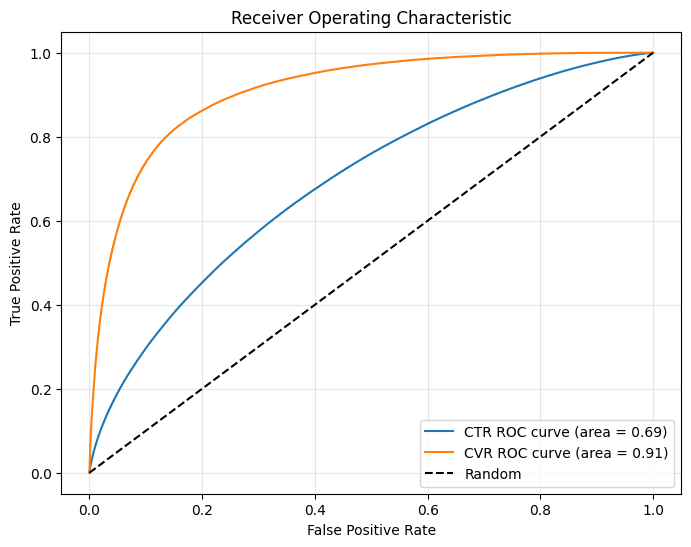

In [ ]:
import os
from datasets import Dataset
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial
import torch
from Ads import Solver


B = 2048
WORKERS = 6

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)

filepath = "../../datasets/criteo_attribution_dataset/processed"
test_df = Dataset.from_parquet(os.path.join(filepath, 'val/val.parquet'))

test_dataset = AdsDataset(data= test_df)
test_ld = DataLoader(dataset=test_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

# load last checkpoint
checkpoint_dir = "./checkpoints/fullRanker"
checkpoint = torch.load(os.path.join(checkpoint_dir, f"last_checkpoint.pth"))
full_model.load_state_dict(checkpoint["model_state_dict"])

predictions = [[] for _ in range(len(final_task_dims))]
targets = [[] for _ in range(len(final_task_dims))]
full_model.eval()
nbatches = len(test_ld)
device = "cpu"
with torch.no_grad():
    for counter, batch in enumerate(test_ld):
        print(f"[{counter}/{nbatches}]")
        
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        x, t = Solver._build_x(batch)

        try:
            task_logits = full_model(x)
            for task in range(len(task_logits)):
                batch_probs = torch.nn.functional.sigmoid(task_logits[task])

                predictions[task].append(batch_probs)
                targets[task].append(t[task])
        except Exception as e:
            print(e)



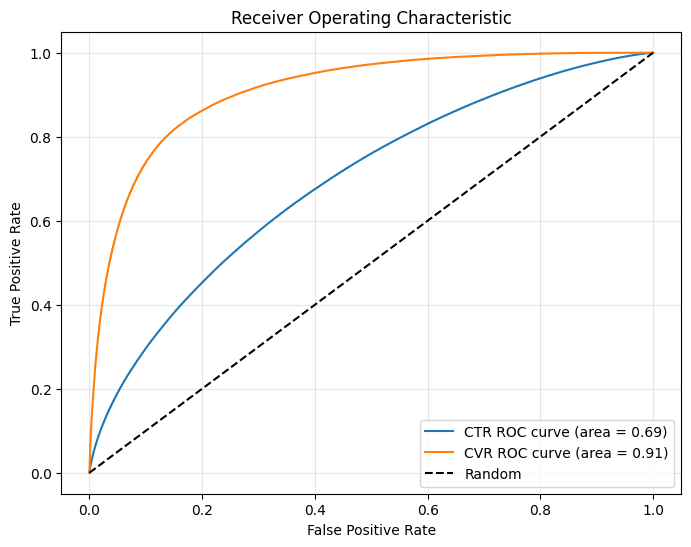

In [20]:
# ROC AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
tasks = ["CTR", "CVR"]
for t in range(len(final_task_dims)):
    probs = torch.cat(predictions[t], dim=0).cpu().numpy()
    target = torch.cat(targets[t], dim=0).cpu().numpy()

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(target, probs)
    roc_auc = auc(fpr, tpr)

    # Plot both curves on same figure
    plt.plot(fpr, tpr, label=f'{tasks[t]} ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [19]:
import torch.nn.functional as F
#  Normalized Entropy (NE)
# average log-loss of a model divided by the average log-loss of a baseline model that predicts the global (CTR) for every impression
tasks = ["CTR", "CVR"]
for t in range(len(final_task_dims)):
    probs = torch.cat(predictions[t], dim=0)
    target = torch.cat(targets[t], dim=0)

    NE = F.binary_cross_entropy(input=probs, target=target, reduction='mean') / F.binary_cross_entropy(input=torch.full_like(target, target.mean()), target=target, reduction='mean')


    print(f"Normalized Entropy ({tasks[t]}): {NE}")


Normalized Entropy (CTR): 0.9128009676933289
Normalized Entropy (CVR): 0.6583004593849182


CVR performance is unusually high, so there is probably a data leakage. I will let myself from the future handle this :)

## Train Early-Stage Ranker

3 separate strategies

- Strategy 1: 2 tasks (CTR and CVR) without distillation
- Strategy 2: 2 tasks (CTR and CVR) with distillation, where each objective function includes both soft(teacher) and hard(ground-truth) targets
- strategy 3: 4 tasks (CTR, CVR, CTR distill, CVR distill) with distillation, where each objective function includes either hard or soft targets

In [2]:
from Ads import EarlyRanker, EmbeddingLayer

# now that we have a functional DLRM tower class, we can split and represent user and item (streaming context features if we had them...) features separately

# for simplicity, keep DLRM Tower bottom and top MLPs identical between user and ad features
bottom_mlp_layers = [256, 64]
projection_layer = 128
emb_layers = {
    "uid": int(2e6),
    "campaign": 401, # +1 for null at index 400
    "cat1": 10,
    "cat2": 70,
    "cat3": 1829,
    "cat4": 21,
    "cat5": 51,
    "cat6": 30,
    "cat7": 57196,
    "cat8": 11,
    "cat9": 30,
}

sparse_features = { 
    "user" : ["uid", "last_n_click_campaigns_1D", "last_n_conversion_campaigns_1D"],
    "ad"   : ["campaign", "cat1", "cat2", "cat3", "cat4", "cat5", "cat6", "cat7", "cat8", "cat9"]
}


E = EmbeddingLayer(emb_layers=emb_layers, emb_dim=bottom_mlp_layers[-1])

# define user and ad tower params
base_params = {
    "bottom_mlp_layers" : bottom_mlp_layers,
    "projection_layer" : projection_layer,
    "embs" : E.embs,
    "dense_num" : 0,
    "device" : "cpu"
}
# copy to get independent dicts
u_params  = {**base_params, "sparse_num": len(sparse_features["user"])}
ad_params = {**base_params, "sparse_num": len(sparse_features["ad"])}

shared_dims = [512, 256]
# CTR, CVR
task_dims = [[128, 1], [128, 1]]

early_model = EarlyRanker(
    shared_dims = shared_dims,
    task_dims = task_dims,
    u_params = u_params,
    ad_params = ad_params
)


In [3]:
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial
from datasets import Dataset
import os

filepath = "../../datasets/criteo_attribution_dataset/processed"
train_df = Dataset.from_parquet(os.path.join(filepath, 'train/train.parquet'))

B = 2048
WORKERS = 6

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)


train_dataset = AdsDataset(data= train_df)
train_ld = DataLoader(dataset=train_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

Strategy 1

In [5]:
# train
import torch
from Ads import Solver
import os

checkpoint_dir = "./checkpoints/earlyRanker_1"
os.makedirs(checkpoint_dir, exist_ok=True)


# define optimizer
emb_params = []
dense_params = []

for name, p in early_model.named_parameters():
    if not p.requires_grad:
        continue
    if "embs" in name:          # covers towers.user.embs.* and towers.ad.embs.*
        emb_params.append(p)
    else:
        dense_params.append(p)

optimizer = torch.optim.Adagrad(
    [
        {"params": emb_params,   "lr": 0.05},
        {"params": dense_params, "lr": 1e-3, "weight_decay": 1e-6},
    ],
    # starting value of the squared gradient accumulator in Adagrad.
    # if initial_accumulator_value=0 -> first step lr / sqrt(0 + ε) → very large update
    # Sparse embeddings (lr=0.05) — most embedding rows are never seen in the first few batches, so G=0 would cause huge updates on first encounter. 1e-8 softens this.
    # Dense MLPs (lr=1e-3) — less critical since dense params are updated every batch and G grows quickly anyway
    # initial_accumulator_value=1e-8,
)

solver = Solver(
    model = early_model,
    data = train_ld,
    optimizer = optimizer,
    device = "cpu",
    epochs = 10,
    checkpoint_dir = checkpoint_dir

)

solver.train()



[0/10] Loss: 0.731269 time: 47.36728395223618m
Checkpoint saved at ./checkpoints/earlyRanker_1/checkpoint_epoch_0.pth
Checkpoint saved at ./checkpoints/earlyRanker_1/last_checkpoint.pth
[1/10] Loss: 0.721822 time: 42.65153149763743m
Checkpoint saved at ./checkpoints/earlyRanker_1/checkpoint_epoch_1.pth
Checkpoint saved at ./checkpoints/earlyRanker_1/last_checkpoint.pth


KeyboardInterrupt: 

In [ ]:
import os
from datasets import Dataset
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial
import torch
from Ads import Solver


B = 2048
WORKERS = 6

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)

filepath = "../../datasets/criteo_attribution_dataset/processed"
test_df = Dataset.from_parquet(os.path.join(filepath, 'val/val.parquet'))

test_dataset = AdsDataset(data= test_df)
test_ld = DataLoader(dataset=test_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

# load last checkpoint
checkpoint_dir = "./checkpoints/earlyRanker_1"
checkpoint = torch.load(os.path.join(checkpoint_dir, f"last_checkpoint.pth"))
early_model.load_state_dict(checkpoint["model_state_dict"])

predictions = [[] for _ in range(len(task_dims))]
targets = [[] for _ in range(len(task_dims))]

early_model.eval()
nbatches = len(test_ld)
device = "cpu"
k = 20
total_final_cost = total_early_cost = 0
with torch.no_grad():
    for counter, batch in enumerate(test_ld):
        print(f"[{counter}/{nbatches}]")
        
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        costs = batch["cost"].float()

        x, t = Solver._build_x(batch)

        try:
            task_logits = early_model(x = x)
            for task in range(len(task_logits)):
                batch_probs = torch.nn.functional.sigmoid(task_logits[task])

                predictions[task].append(batch_probs)
                targets[task].append(t[task])
            
            # soft recall: compare top-k costs between early and final ranker
            # for simplicity, use CTR for top-k selection, ideally it would be a total value equation combining multiple tasks
            final_logits = full_model(x)[0].squeeze(-1)   # CTR logit, (B,)
            early_logits = task_logits[0].squeeze(-1)

            k_actual = min(k, final_logits.size(0))
            final_topk_idx = torch.topk(final_logits, k_actual).indices  # golden set
            early_topk_idx = torch.topk(early_logits, k_actual).indices

            total_final_cost += costs[final_topk_idx].sum().item()
            total_early_cost += costs[early_topk_idx].sum().item()

        except Exception as e:
            print(e)

# soft recall score
# calculate soft recall
# given a batch, select top-k ads predicted by the final ranker (golden set)
# for the same batch, select top-k ads predicted by the early-stage ranker
# soft recall = sum(top-k ad costs) / sum(golden set costs)

# I should be using the total value equation instead of the ad cost - meta paper [6] section 1
# "total value is a combination of three major factors: 1) The bid placed
# by an advertiser for that ad. 2) Estimated action rates representing
# the probability of the desired outcome (e.g. click, conversion) after
# showing the ad to a user. 3) Ads quality [2] capturing the feedback
# from user on their ads experience."

# for simplicity, I use the cost as a proxy to the total value equation

# this is for offline, but for online metric we can utilize Total Value Divergence (meta paper [6] equation 5)
soft_recall_score = total_early_cost / total_final_cost if total_final_cost > 0 else 0.0
print(f"\nSoft Recall @{k}: {soft_recall_score:.4f}")
print(f"  Early-stage 1 total cost: {total_early_cost:.2f}")
print(f"  Final ranker total cost (golden): {total_final_cost:.2f}")

[0/1705]
[1/1705]
[2/1705]
[3/1705]
[4/1705]
[5/1705]
[6/1705]
[7/1705]
[8/1705]
[9/1705]
[10/1705]
[11/1705]
[12/1705]
[13/1705]
[14/1705]
[15/1705]
[16/1705]
[17/1705]
[18/1705]
[19/1705]
[20/1705]
[21/1705]
[22/1705]
[23/1705]
[24/1705]
[25/1705]
[26/1705]
[27/1705]
[28/1705]
[29/1705]
[30/1705]
[31/1705]
[32/1705]
[33/1705]
[34/1705]
[35/1705]
[36/1705]
[37/1705]
[38/1705]
[39/1705]
[40/1705]
[41/1705]
[42/1705]
[43/1705]
[44/1705]
[45/1705]
[46/1705]
[47/1705]
[48/1705]
[49/1705]
[50/1705]
[51/1705]
[52/1705]
[53/1705]
[54/1705]
[55/1705]
[56/1705]
[57/1705]
[58/1705]
[59/1705]
[60/1705]
[61/1705]
[62/1705]
[63/1705]
[64/1705]
[65/1705]
[66/1705]
[67/1705]
[68/1705]
[69/1705]
[70/1705]
[71/1705]
[72/1705]
[73/1705]
[74/1705]
[75/1705]
[76/1705]
[77/1705]
[78/1705]
[79/1705]
[80/1705]
[81/1705]
[82/1705]
[83/1705]
[84/1705]
[85/1705]
[86/1705]
[87/1705]
[88/1705]
[89/1705]
[90/1705]
[91/1705]
[92/1705]
[93/1705]
[94/1705]
[95/1705]
[96/1705]
[97/1705]
[98/1705]
[99/1705]
[100/1705]

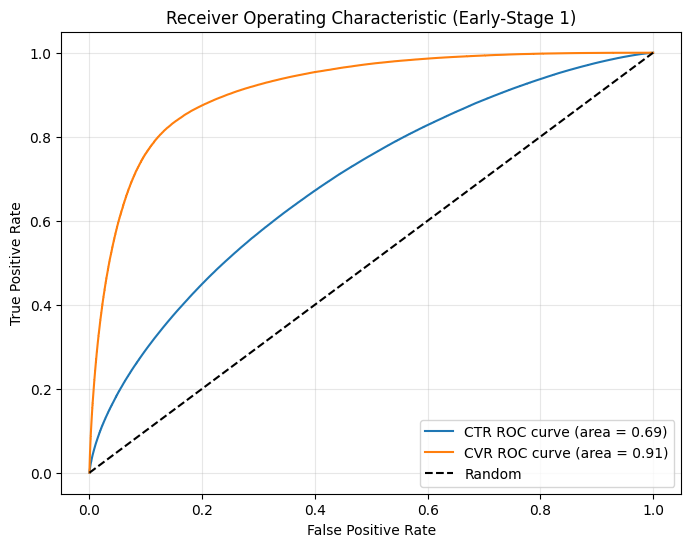

In [6]:
# Calculate ROC-AUC and NE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
tasks = ["CTR", "CVR"]
for t in range(len(task_dims)):
    probs = torch.cat(predictions[t], dim=0).cpu().numpy()
    target = torch.cat(targets[t], dim=0).cpu().numpy()

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(target, probs)
    roc_auc = auc(fpr, tpr)

    # Plot both curves on same figure
    plt.plot(fpr, tpr, label=f'{tasks[t]} ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Early-Stage 1)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

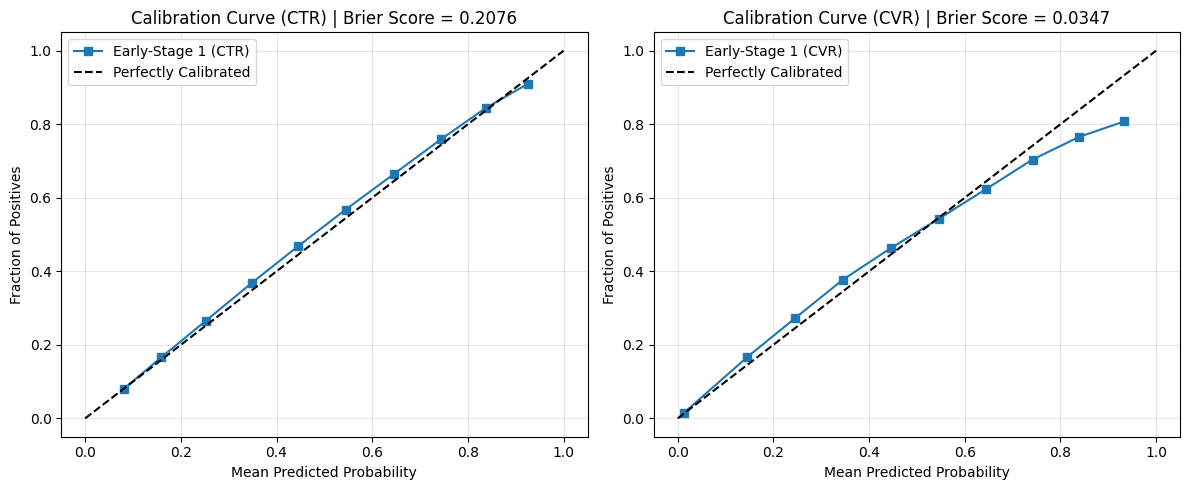

In [8]:
# check the calibration curve
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


tasks = ["CTR", "CVR"]
n_real_tasks = len(tasks)

fig, axes = plt.subplots(1, n_real_tasks, figsize=(12, 5))

for t in range(n_real_tasks):
    probs = torch.cat(predictions[t], dim=0).cpu().numpy()
    target = torch.cat(targets[t], dim=0).cpu().numpy()

    prob_true, prob_pred = calibration_curve(target, probs, n_bins=10)

    # Calculate the Brier score, measurement for calibration and sharpness
    brier_score = brier_score_loss(target, probs)

    axes[t].plot(prob_pred, prob_true, 's-', label=f'Early-Stage 1 ({tasks[t]})')
    axes[t].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    axes[t].set_ylabel('Fraction of Positives')
    axes[t].set_xlabel('Mean Predicted Probability')
    axes[t].set_title(f'Calibration Curve ({tasks[t]}) | Brier Score = {brier_score:.4f}')
    axes[t].legend()
    axes[t].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Strategy 2

In [6]:
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial
from datasets import Dataset
import os

filepath = "../../datasets/criteo_attribution_dataset/processed"
train_df = Dataset.from_parquet(os.path.join(filepath, 'train/train.parquet'))

B = 2048
WORKERS = 6

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)


train_dataset = AdsDataset(data= train_df)
train_ld = DataLoader(dataset=train_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

In [9]:
# train
import torch
from Ads import Solver
import os
from Ads import EarlyRanker

# load last checkpoint for a teacher model
checkpoint_dir = "./checkpoints/fullRanker"
checkpoint = torch.load(os.path.join(checkpoint_dir, f"last_checkpoint.pth"))
full_model.load_state_dict(checkpoint["model_state_dict"])

full_model.eval()


checkpoint_dir = "./checkpoints/earlyRanker_2"
os.makedirs(checkpoint_dir, exist_ok=True)


# define optimizer
emb_params = []
dense_params = []

shared_dims = [512, 256]
# CTR, CVR
task_dims = [[128, 1], [128, 1]]

# initialize a new model
early_model = EarlyRanker(
    shared_dims = shared_dims,
    task_dims = task_dims,
    u_params = u_params,
    ad_params = ad_params
)

for name, p in early_model.named_parameters():
    if not p.requires_grad:
        continue
    if "embs" in name:          # covers towers.user.embs.* and towers.ad.embs.*
        emb_params.append(p)
    else:
        dense_params.append(p)

optimizer = torch.optim.Adagrad(
    [
        {"params": emb_params,   "lr": 0.05},
        {"params": dense_params, "lr": 1e-3, "weight_decay": 1e-6},
    ],
    # starting value of the squared gradient accumulator in Adagrad.
    # if initial_accumulator_value=0 -> first step lr / sqrt(0 + ε) → very large update
    # Sparse embeddings (lr=0.05) — most embedding rows are never seen in the first few batches, so G=0 would cause huge updates on first encounter. 1e-8 softens this.
    # Dense MLPs (lr=1e-3) — less critical since dense params are updated every batch and G grows quickly anyway
    # initial_accumulator_value=1e-8,
)


solver = Solver(
    model = early_model,
    data = train_ld,
    optimizer = optimizer,
    device = "cpu",
    epochs = 10,
    checkpoint_dir = checkpoint_dir,
    distillation_weights = [3, 3],
    teacher = full_model

)

solver.train()



[0/10] Loss: 3.827918 time: 43.476562015215556m
Checkpoint saved at ./checkpoints/earlyRanker_2/checkpoint_epoch_0.pth
Checkpoint saved at ./checkpoints/earlyRanker_2/last_checkpoint.pth
[1/10] Loss: 3.958560 time: 87.07844413121542m
Checkpoint saved at ./checkpoints/earlyRanker_2/checkpoint_epoch_1.pth
Checkpoint saved at ./checkpoints/earlyRanker_2/last_checkpoint.pth
[2/10] Loss: 4.021563 time: 63.0281667192777m
Checkpoint saved at ./checkpoints/earlyRanker_2/checkpoint_epoch_2.pth
Checkpoint saved at ./checkpoints/earlyRanker_2/last_checkpoint.pth
[3/10] Loss: 4.057034 time: 88.44844198624293m
Checkpoint saved at ./checkpoints/earlyRanker_2/checkpoint_epoch_3.pth
Checkpoint saved at ./checkpoints/earlyRanker_2/last_checkpoint.pth
[4/10] Loss: 4.081190 time: 64.04756973187129m
Checkpoint saved at ./checkpoints/earlyRanker_2/checkpoint_epoch_4.pth
Checkpoint saved at ./checkpoints/earlyRanker_2/last_checkpoint.pth
[5/10] Loss: 4.098505 time: 65.48050488233567m
Checkpoint saved at ./c

In [3]:
import os
from datasets import Dataset
from torch.utils.data import DataLoader
from Ads import AdsDataset
from functools import partial
import torch
from Ads import Solver


B = 2048
WORKERS = 6

# Define voc size for user and campaign ids
user_v = emb_layers["uid"]
campaign_v = emb_layers["campaign"]


# Create a partial function with the arguments bound
collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)

filepath = "../../datasets/criteo_attribution_dataset/processed"
test_df = Dataset.from_parquet(os.path.join(filepath, 'val/val.parquet'))

test_dataset = AdsDataset(data= test_df)
test_ld = DataLoader(dataset=test_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

# load last checkpoint
checkpoint_dir = "./checkpoints/earlyRanker_2"
checkpoint = torch.load(os.path.join(checkpoint_dir, f"last_checkpoint.pth"))
early_model.load_state_dict(checkpoint["model_state_dict"])

predictions = [[] for _ in range(len(task_dims))]
targets = [[] for _ in range(len(task_dims))]

early_model.eval()
nbatches = len(test_ld)
device = "cpu"

k = 20
total_final_cost = total_early_cost = 0
with torch.no_grad():
    for counter, batch in enumerate(test_ld):
        print(f"[{counter}/{nbatches}]")
        
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        costs = batch["cost"].float()

        x, t = Solver._build_x(batch)

        try:
            task_logits = early_model(x = x)
            for task in range(len(task_logits)):
                batch_probs = torch.nn.functional.sigmoid(task_logits[task])

                predictions[task].append(batch_probs)
                targets[task].append(t[task])
            
            # soft recall: compare top-k costs between early and final ranker
            # for simplicity, use CTR for top-k selection, ideally it would be a total value equation combining multiple tasks
            final_logits = full_model(x)[0].squeeze(-1)   # CTR logit, (B,)
            early_logits = task_logits[0].squeeze(-1)

            k_actual = min(k, final_logits.size(0))
            final_topk_idx = torch.topk(final_logits, k_actual).indices  # golden set
            early_topk_idx = torch.topk(early_logits, k_actual).indices

            total_final_cost += costs[final_topk_idx].sum().item()
            total_early_cost += costs[early_topk_idx].sum().item()

        except Exception as e:
            print(e)

# soft recall score
soft_recall_score = total_early_cost / total_final_cost if total_final_cost > 0 else 0.0
print(f"\nSoft Recall @{k}: {soft_recall_score:.4f}")
print(f"  Early-stage 2 total cost: {total_early_cost:.2f}")
print(f"  Final ranker total cost (golden): {total_final_cost:.2f}")

[0/1705]
[1/1705]
[2/1705]
[3/1705]
[4/1705]
[5/1705]
[6/1705]
[7/1705]
[8/1705]
[9/1705]
[10/1705]
[11/1705]
[12/1705]
[13/1705]
[14/1705]
[15/1705]
[16/1705]
[17/1705]
[18/1705]
[19/1705]
[20/1705]
[21/1705]
[22/1705]
[23/1705]
[24/1705]
[25/1705]
[26/1705]
[27/1705]
[28/1705]
[29/1705]
[30/1705]
[31/1705]
[32/1705]
[33/1705]
[34/1705]
[35/1705]
[36/1705]
[37/1705]
[38/1705]
[39/1705]
[40/1705]
[41/1705]
[42/1705]
[43/1705]
[44/1705]
[45/1705]
[46/1705]
[47/1705]
[48/1705]
[49/1705]
[50/1705]
[51/1705]
[52/1705]
[53/1705]
[54/1705]
[55/1705]
[56/1705]
[57/1705]
[58/1705]
[59/1705]
[60/1705]
[61/1705]
[62/1705]
[63/1705]
[64/1705]
[65/1705]
[66/1705]
[67/1705]
[68/1705]
[69/1705]
[70/1705]
[71/1705]
[72/1705]
[73/1705]
[74/1705]
[75/1705]
[76/1705]
[77/1705]
[78/1705]
[79/1705]
[80/1705]
[81/1705]
[82/1705]
[83/1705]
[84/1705]
[85/1705]
[86/1705]
[87/1705]
[88/1705]
[89/1705]
[90/1705]
[91/1705]
[92/1705]
[93/1705]
[94/1705]
[95/1705]
[96/1705]
[97/1705]
[98/1705]
[99/1705]
[100/1705]

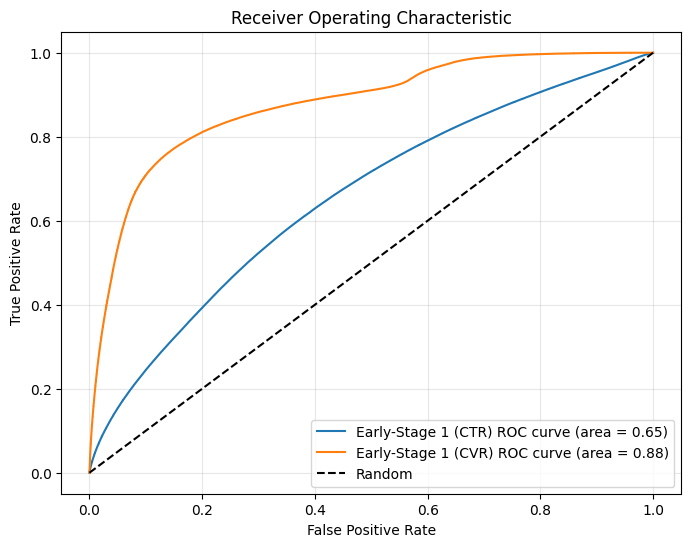

In [4]:
# Calculate ROC-AUC and NE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
tasks = ["CTR", "CVR"]
for t in range(len(task_dims)):
    probs = torch.cat(predictions[t], dim=0).cpu().numpy()
    target = torch.cat(targets[t], dim=0).cpu().numpy()

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(target, probs)
    roc_auc = auc(fpr, tpr)

    # Plot both curves on same figure
    plt.plot(fpr, tpr, label=f'Early-Stage 1 ({tasks[t]}) ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

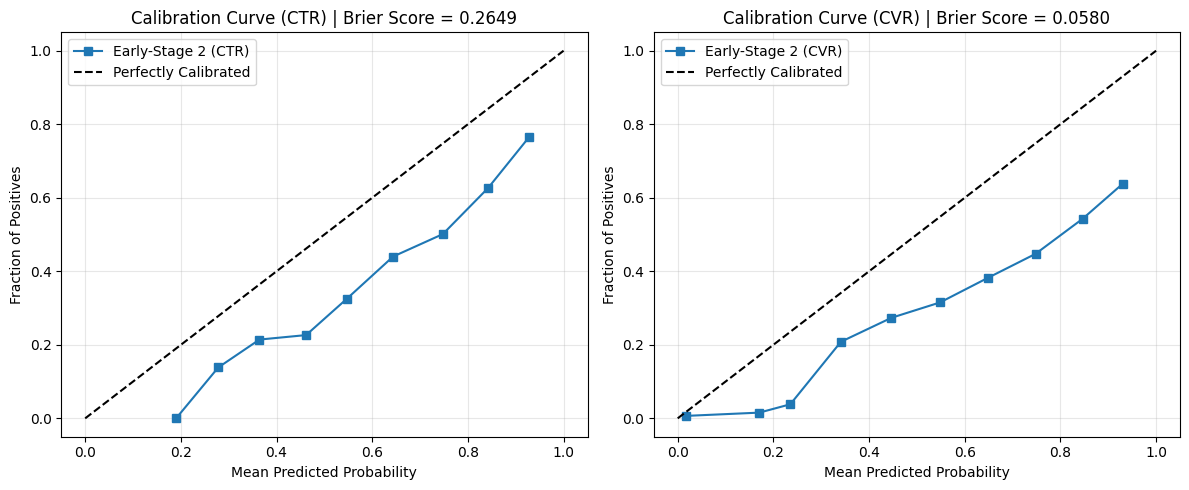

In [7]:
# check the calibration curve
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


tasks = ["CTR", "CVR"]
n_real_tasks = len(tasks)

fig, axes = plt.subplots(1, n_real_tasks, figsize=(12, 5))

for t in range(n_real_tasks):
    probs = torch.cat(predictions[t], dim=0).cpu().numpy()
    target = torch.cat(targets[t], dim=0).cpu().numpy()

    prob_true, prob_pred = calibration_curve(target, probs, n_bins=10)

    # Calculate the Brier score, measurement for calibration and sharpness
    brier_score = brier_score_loss(target, probs)

    axes[t].plot(prob_pred, prob_true, 's-', label=f'Early-Stage 2 ({tasks[t]})')
    axes[t].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    axes[t].set_ylabel('Fraction of Positives')
    axes[t].set_xlabel('Mean Predicted Probability')
    axes[t].set_title(f'Calibration Curve ({tasks[t]}) | Brier Score = {brier_score:.4f}')
    axes[t].legend()
    axes[t].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Strategy 3

For faster train/eval iteration, I used ray.Data and Ray.Train to train the model and ray.map_batches to evaluate on the processed eval data. Simple DDP implementation with 2 workers (m5.2xlarge) is able to complete the jub in 2.13 hours. Training Strategy 2, which has less task heads, took 11.15 hours on my laptop.

In [ ]:
# # train
# import torch
# from Ads import Solver
# import os

# # load last checkpoint for a teacher model
# checkpoint_dir = "./checkpoints/fullRanker"
# checkpoint = torch.load(os.path.join(checkpoint_dir, f"last_checkpoint.pth"))
# full_model.load_state_dict(checkpoint["model_state_dict"])

# full_model.eval()

# checkpoint_dir = "./checkpoints/earlyRanker_3"
# os.makedirs(checkpoint_dir, exist_ok=True)


# # define optimizer
# emb_params = []
# dense_params = []

# # initialize a new model
# # CTR, CVR, CTR distill, CVR distill
# task_dims = [[128, 1], [128, 1], [128, 1], [128, 1]]

# early_model = EarlyRanker(
#     shared_dims = shared_dims,
#     task_dims = task_dims,
#     u_params = u_params,
#     ad_params = ad_params
# )

# for name, p in early_model.named_parameters():
#     if not p.requires_grad:
#         continue
#     if "embs" in name:          # covers towers.user.embs.* and towers.ad.embs.*
#         emb_params.append(p)
#     else:
#         dense_params.append(p)

# optimizer = torch.optim.Adagrad(
#     [
#         {"params": emb_params,   "lr": 0.05},
#         {"params": dense_params, "lr": 1e-3, "weight_decay": 1e-6},
#     ],
#     # starting value of the squared gradient accumulator in Adagrad.
#     # if initial_accumulator_value=0 -> first step lr / sqrt(0 + ε) → very large update
#     # Sparse embeddings (lr=0.05) — most embedding rows are never seen in the first few batches, so G=0 would cause huge updates on first encounter. 1e-8 softens this.
#     # Dense MLPs (lr=1e-3) — less critical since dense params are updated every batch and G grows quickly anyway
#     # initial_accumulator_value=1e-8,
# )

# solver = Solver(
#     model = early_model,
#     data = train_ld,
#     optimizer = optimizer,
#     device = "cpu",
#     epochs = 10,
#     checkpoint_dir = checkpoint_dir,
#     distillation_weights = [3, 3],
#     full_model = full_model,
#     distillation_tasks = [2, 3]
# )

# solver.train()



In [ ]:
# import os
# from datasets import Dataset
# from torch.utils.data import DataLoader
# from Ads import AdsDataset
# from functools import partial
# import torch
# from Ads import Solver


# B = 2048
# WORKERS = 6

# # Define voc size for user and campaign ids
# user_v = emb_layers["uid"]
# campaign_v = emb_layers["campaign"]


# # Create a partial function with the arguments bound
# collate_with_args = partial(AdsDataset._collate_batch, user_v=user_v, campaign_v=campaign_v)

# filepath = "../../datasets/criteo_attribution_dataset/processed"
# test_df = Dataset.from_parquet(os.path.join(filepath, 'val/val.parquet'))

# test_dataset = AdsDataset(data= test_df)
# test_ld = DataLoader(dataset=test_dataset, batch_size=B, shuffle=False, num_workers=WORKERS, collate_fn=collate_with_args)

# # load last checkpoint
# checkpoint_dir = "./checkpoints/earlyRanker_3"
# checkpoint = torch.load(os.path.join(checkpoint_dir, f"last_checkpoint.pth"))
# early_model.load_state_dict(checkpoint["model_state_dict"])

# predictions = [[] for _ in range(len(task_dims))]
# targets = [[] for _ in range(len(task_dims))]

# early_model.eval()
# nbatches = len(test_ld)
# device = "cpu"
# with torch.no_grad():
#     for counter, batch in enumerate(test_ld):
#         print(f"[{counter}/{nbatches}]")
        
#         batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
#         costs = batch["cost"].float()

#         x, t = Solver._build_x(batch)

#         try:
#             task_logits = early_model(x = x)
#             for task in range(len(task_logits)):
#                 batch_probs = torch.nn.functional.sigmoid(task_logits[task])

#                 predictions[task].append(batch_probs)
#                 targets[task].append(t[task])
            
#             # soft recall: compare top-k costs between early and final ranker
#             # for simplicity, use CTR for top-k selection, ideally it would be a total value equation combining multiple tasks
#             final_logits = full_model(x)[0].squeeze(-1)   # CTR logit, (B,)
#             early_logits = task_logits[0].squeeze(-1)

#             k_actual = min(k, final_logits.size(0))
#             final_topk_idx = torch.topk(final_logits, k_actual).indices  # golden set
#             early_topk_idx = torch.topk(early_logits, k_actual).indices

#             total_final_cost += costs[final_topk_idx].sum().item()
#             total_early_cost += costs[early_topk_idx].sum().item()

#         except Exception as e:
#             print(e)

# # soft recall score
# soft_recall_score = total_early_cost / total_final_cost if total_final_cost > 0 else 0.0
# print(f"\nSoft Recall @{k}: {soft_recall_score:.4f}")
# print(f"  Early-stage 3 total cost: {total_early_cost:.2f}")
# print(f"  Final ranker total cost (golden): {total_final_cost:.2f}")

In [ ]:
from datasets import Dataset

# read eval data from s3 bucket (ray cluster was deployed in aws)
data_path = "<BUCKET-NAME>/ads/earlyRanker/predictions/*"
eval_df = Dataset.from_parquet(f"s3://{data_path}")
eval_df
# eval_np = eval_df.with_format("numpy")


/Users/paataugrekhelidze/Projects/Recsys/ranking/ads_Moe/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 3491439 examples [00:00, 13527501.87 examples/s]


Dataset({
    features: ['ctr_prob', 'cvr_prob', 'ctr_distill_prob', 'cvr_distill_prob', 'ctr_target', 'cvr_target'],
    num_rows: 3491439
})

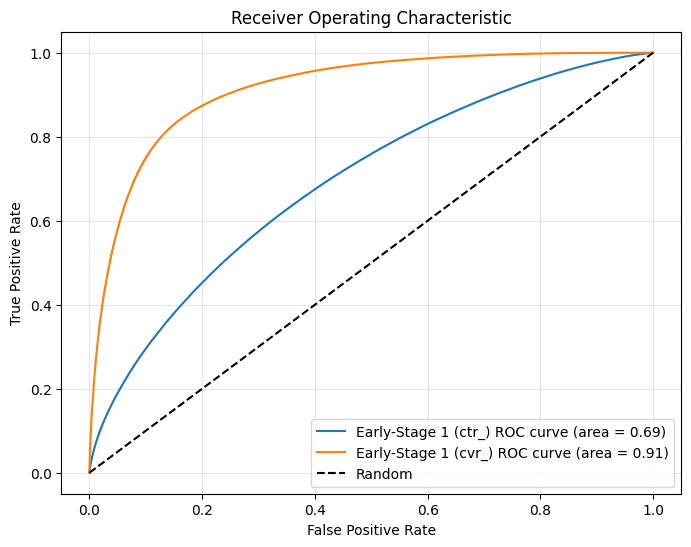

In [2]:
# Calculate ROC-AUC and NE
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(8, 6))
tasks = ["ctr_", "cvr_"]
for task in tasks:
    # probs = torch.cat(eval_df[task+"prob"], dim=0).cpu().numpy()
    # target = torch.cat(eval_df[task+"target"], dim=0).cpu().numpy()
    probs = eval_df[task+"prob"]
    target = eval_df[task+"target"]

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(target, probs)
    roc_auc = auc(fpr, tpr)

    # Plot both curves on same figure
    plt.plot(fpr, tpr, label=f'Early-Stage 1 ({task}) ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

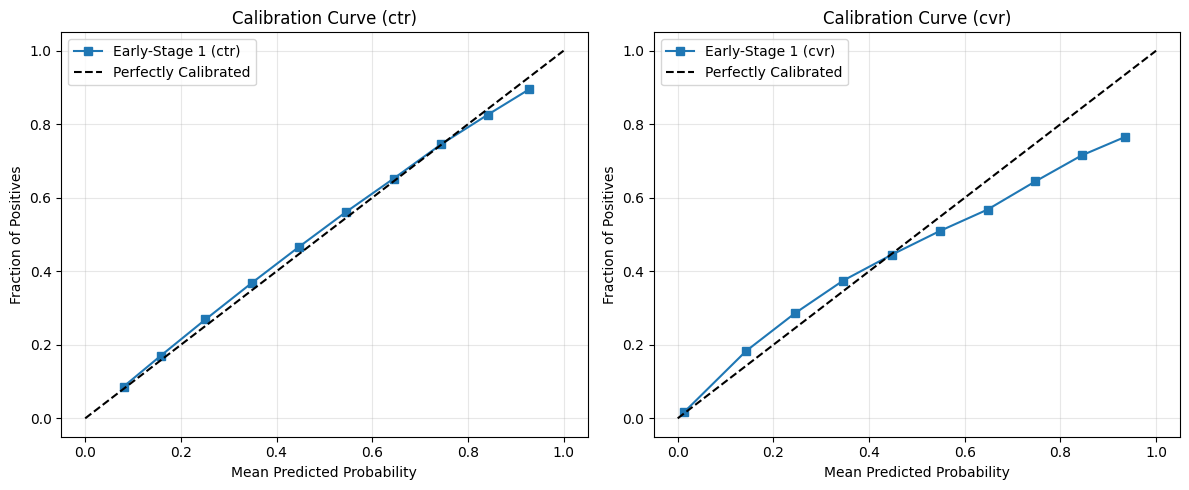

In [5]:
# check the calibration curve
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve


tasks = ["ctr_", "cvr_"]
# n_real_tasks = len(tasks)

fig, axes = plt.subplots(1, len(tasks), figsize=(12, 5))

for t in range(len(tasks)):
    # probs = torch.cat(eval_df[task+"prob"], dim=0).cpu().numpy()
    # target = torch.cat(eval_df[task+"target"], dim=0).cpu().numpy()
    probs = eval_df[tasks[t]+"prob"]
    target = eval_df[tasks[t]+"target"]

    prob_true, prob_pred = calibration_curve(target, probs, n_bins=10)

    axes[t].plot(prob_pred, prob_true, 's-', label=f'Early-Stage 1 ({tasks[t][:-1]})')
    axes[t].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    axes[t].set_ylabel('Fraction of Positives')
    axes[t].set_xlabel('Mean Predicted Probability')
    axes[t].set_title(f'Calibration Curve ({tasks[t][:-1]})')
    axes[t].legend()
    axes[t].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Compared to distillation with 2 tasks (strategy 2), distillation with 4 tasks (strategy 3) provides a better performance as well as a much better calibration on all tasks. Strategy 2 also requires a manual adjustment for objective weights to find a better balance between soft and hard targets, which is not necessary in strategy 3.